**Author:** Biswajit Jana
**Date:** July 5, 2026

# JWST SN 1987A: filter-dependent morphology

**Scientific question:** How does the ring-to-ejecta balance change across four NIRCam filters?

## Scientific audit protocol

This notebook is one part of a five-notebook case study of SN 1987A. It uses
either compact cutouts from named calibrated MAST FITS products, official NASA
release frames with their processing limits stated, or a peer-reviewed table
whose DOI and units are preserved. The object, coordinate, telescope,
instrument, filter, observing date, and original product name are kept in the
shared manifest. No image is presented as an unexplained illustration.

### Observation versus display

A calibrated FITS pixel and a public colour image are not interchangeable.
The JWST cutouts retain surface brightness in MJy/sr and an error extension.
They can support aperture sums and wavelength-dependent comparisons after
background subtraction. The Hubble release frames were already aligned,
combined, stretched, colour-mapped, compressed, and possibly resampled before
download. They can show where structures appear and can make a useful dated
animation, but their RGB values are not physical flux. The time-lapse notebook
therefore measures only within-frame morphology; calibrated brightness change
is analysed separately from published HST photometry.

An RGB composite is also a mapping, not what a human eye would see. Each
monochromatic infrared channel is assigned a visible colour and stretched to
reveal structure. The notebook records the assignment and shows every input
channel beside the composite. Scientific measurements use the unstretched
arrays, never the rendered RGB pixels. A colour difference is not called a
chemical detection: broad filters mix continuum and emission lines, and a
spectral or narrow-band analysis is needed to identify a constituent.

### Registration, resolution, and uncertainty

Images from different filters are placed on one celestial WCS grid before
pixel-level comparison. The code uses the output sky coordinates rather than
assuming equal array sizes or identical centring. When filters with different
point-spread functions are compared, the sharper images are blurred to a
common approximate resolution. The calculation is repeated across plausible
apertures or smoothing widths so one attractive processing choice cannot carry
the conclusion.

Background is measured away from the remnant. Random aperture uncertainty is
estimated from background scatter or from the published measurement error.
This does not include every calibration, PSF, aperture, or correlated-noise
term, so formal intervals are not promoted to publication-grade errors. For
the literature light curve, residual resampling is used because scatter about
the trend is more realistic than treating the very small tabulated statistical
errors as the only uncertainty.

### Claim boundary

“Validated” means the narrow archive measurement survived the checks named in
this notebook. “Reproduction” means a published table was independently
reanalysed and compared with the paper's conclusion. “Exploration” means the
product is useful for visual or method development but cannot support a
calibrated physical claim. None of these labels means a new supernova,
constituent, compact object, or explosion mechanism has been discovered.

The figures and small tables are saved beside the executed notebook. Each
`result.json` names the evidence figures, reusable artifacts, limitations,
quality checks, and provenance that feed the project dashboard. A null result,
unstable value, or mismatch is retained rather than edited away. This keeps the
repository useful as a learning record and makes the next required observation
or model explicit.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from PIL import Image, ImageDraw
from scipy import ndimage, stats
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/sn1987a')
assert DATA.is_dir(), 'Run from the notebook folder inside a complete repository checkout.'
TARGET_RA=83.8666125; TARGET_DEC=-69.2697528

def load_fits(name):
    with fits.open(DATA/name,memmap=False) as h:
        sci=np.asarray(h['SCI'].data,float); err=np.asarray(h['ERR'].data,float) if 'ERR' in h else None
        return sci,err,WCS(h['SCI'].header).celestial,h['SCI'].header.copy()

def reproject_array(array,wcs_in,wcs_out,shape_out,order=1):
    yy,xx=np.indices(shape_out,dtype=float); sky=wcs_out.pixel_to_world(xx,yy); sx,sy=wcs_in.world_to_pixel(sky)
    return ndimage.map_coordinates(array,[sy,sx],order=order,mode='constant',cval=np.nan)

def pixel_scale_arcsec(wcs):
    return float(np.mean(proj_plane_pixel_scales(wcs))*3600)

def stretch(array,low=1,high=99.7,a=8):
    lo,hi=np.nanpercentile(array,[low,high]); z=np.clip((array-lo)/(hi-lo),0,1)
    return np.arcsinh(a*z)/np.arcsinh(a)

Set OBSGEO-B to   -16.371046 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478832142.256 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -16.348296 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478590370.632 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -16.371056 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478832242.153 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -16.348305 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478590470.575 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


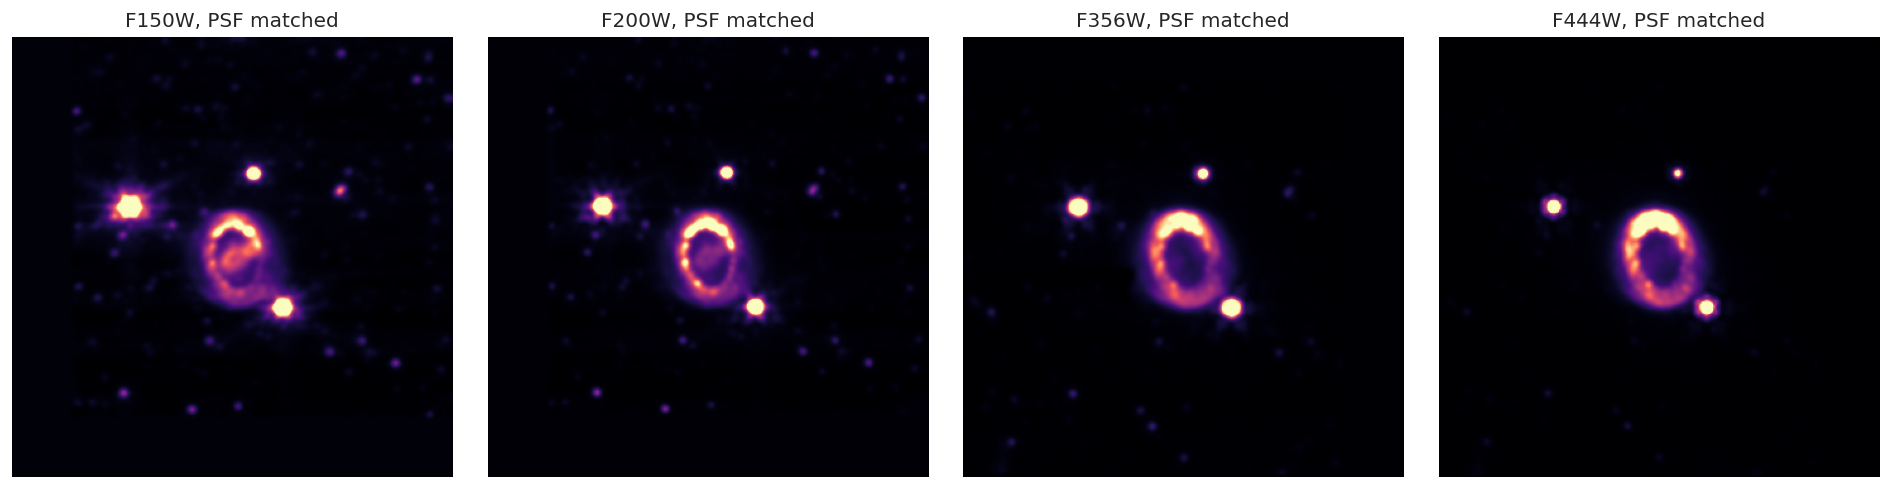

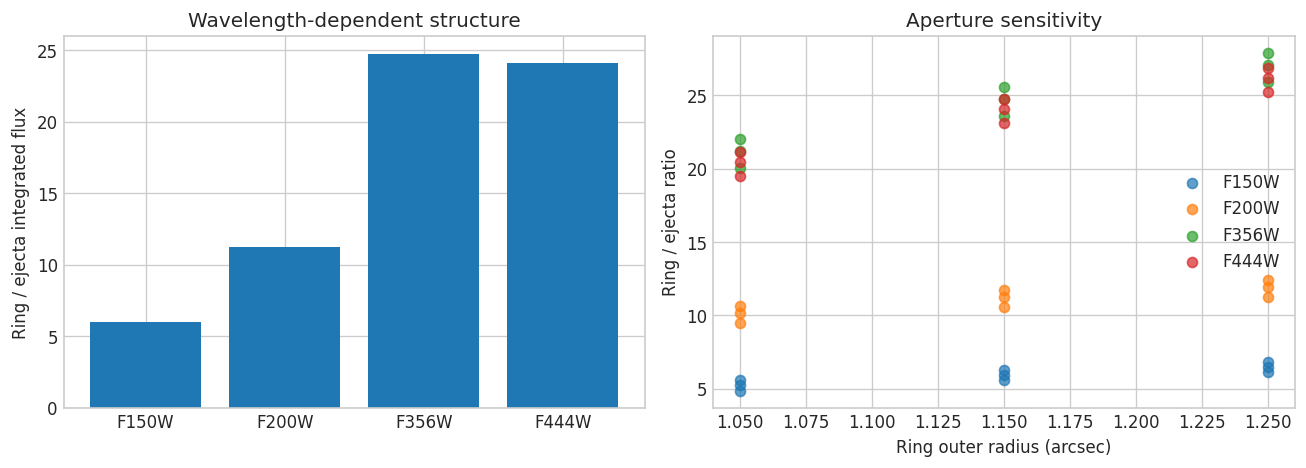

In [2]:
filters=['F150W','F200W','F356W','F444W']; files=[f'jwst_{f.lower()}_2022_cutout.fits' for f in filters]; loaded=[load_fits(name) for name in files]; ref,_,wref,_=loaded[0]; aligned=[]
for sci,err,wcs,header in loaded: aligned.append(reproject_array(sci,wcs,wref,ref.shape))
scale=pixel_scale_arcsec(wref); yy,xx=np.indices(ref.shape); from astropy.coordinates import SkyCoord
cx,cy=wref.world_to_pixel(SkyCoord(TARGET_RA,TARGET_DEC,unit='deg')); radius=np.hypot((xx-cx)*scale,(yy-cy)*scale); pix_sr=(scale/206265)**2
psf={'F150W':.050,'F200W':.066,'F356W':.116,'F444W':.145}; target_fwhm=.145; matched=[]
for filt,array in zip(filters,aligned):
    sigma=np.sqrt(max(target_fwhm**2-psf[filt]**2,0))/2.35482/scale; matched.append(ndimage.gaussian_filter(np.nan_to_num(array,nan=np.nanmedian(array)),sigma))

def aperture_metrics(array,inner=.55,outer=1.15,ejecta=.35):
    bg=(radius>3)&(radius<4.8); b=np.median(array[bg]); scatter=np.std(array[bg]); ring=(radius>inner)&(radius<outer); core=radius<ejecta; conv=pix_sr*1e6
    rf=np.sum(array[ring]-b)*conv; cf=np.sum(array[core]-b)*conv; re=scatter*np.sqrt(ring.sum())*conv; ce=scatter*np.sqrt(core.sum())*conv
    return rf,cf,rf/cf,re,ce
rows=[]
for filt,array in zip(filters,matched):
    rf,cf,ratio,re,ce=aperture_metrics(array); rows.append({'filter':filt,'ring_flux_Jy_proxy':rf,'ejecta_flux_Jy_proxy':cf,'ring_to_ejecta':ratio,'ring_random_error_Jy':re,'ejecta_random_error_Jy':ce})
metrics=pd.DataFrame(rows); metrics.to_csv('jwst_filter_aperture_metrics.csv',index=False)

fig,axes=plt.subplots(1,4,figsize=(16,4))
for ax,array,filt in zip(axes,matched,filters): ax.imshow(array,origin='lower',cmap='magma',vmin=np.percentile(array,3),vmax=np.percentile(array,99.5)); ax.set_title(f'{filt}, PSF matched'); ax.axis('off')
fig.tight_layout(); fig.savefig('jwst_filter_morphology_panels.png',dpi=180); plt.show()

stress=[]
for inner in [.50,.55,.60]:
    for outer in [1.05,1.15,1.25]:
        for filt,array in zip(filters,matched): stress.append((filt,inner,outer,aperture_metrics(array,inner,outer)[2]))
stress=pd.DataFrame(stress,columns=['filter','ring_inner_arcsec','ring_outer_arcsec','ring_to_ejecta']); stress.to_csv('jwst_aperture_sensitivity.csv',index=False)
fig,ax=plt.subplots(1,2,figsize=(11,4)); ax[0].bar(metrics['filter'],metrics.ring_to_ejecta); ax[0].set(ylabel='Ring / ejecta integrated flux',title='Wavelength-dependent structure');
for filt,g in stress.groupby('filter'): ax[1].scatter(g.ring_outer_arcsec,g.ring_to_ejecta,label=filt,alpha=.7)
ax[1].set(xlabel='Ring outer radius (arcsec)',ylabel='Ring / ejecta ratio',title='Aperture sensitivity'); ax[1].legend(); fig.tight_layout(); fig.savefig('jwst_filter_ratios_and_stress.png',dpi=180); plt.show()

In [3]:
span=metrics.ring_to_ejecta.max()/metrics.ring_to_ejecta.min(); results=[f'PSF-matched ring/ejecta ratio spans a factor {span:.2f} across F150W–F444W',f'largest ratio occurs in {metrics.loc[metrics.ring_to_ejecta.idxmax(),"filter"]}',f'result repeated across nine ring-aperture definitions per filter']
result={'id':'2026-08-01-jwst-sn1987a-filter-morphology','title':'JWST SN 1987A: filter-dependent ring/ejecta structure','archive':'MAST · JWST NIRCam','date':'2026-08-01','question':'How does the ring-to-ejecta surface-brightness balance change from 1.5 to 4.44 microns?','sample_size':int(sum(np.isfinite(a).sum() for a in aligned)),'results':results,'validation':'All filters are WCS-aligned, blurred to an approximate F444W PSF, background-subtracted, and repeated over nine aperture choices.','notebook':'mast/2026-08-01-jwst-sn1987a-filter-morphology/notebook.ipynb','hero':'mast/2026-08-01-jwst-sn1987a-filter-morphology/jwst_filter_morphology_panels.png','figures':['mast/2026-08-01-jwst-sn1987a-filter-morphology/jwst_filter_morphology_panels.png','mast/2026-08-01-jwst-sn1987a-filter-morphology/jwst_filter_ratios_and_stress.png'],'research_level':'Validated','claim_type':'Filter-resolved morphology','provenance':['MAST JWST program 1726','calibrated NIRCam I2D F150W, F200W, F356W, F444W','compact cutouts retain MJy/sr and WCS'],'artifacts':['data/sn1987a/jwst_f150w_2022_cutout.fits','data/sn1987a/jwst_f200w_2022_cutout.fits','data/sn1987a/jwst_f356w_2022_cutout.fits','data/sn1987a/jwst_f444w_2022_cutout.fits','mast/2026-08-01-jwst-sn1987a-filter-morphology/jwst_filter_aperture_metrics.csv','mast/2026-08-01-jwst-sn1987a-filter-morphology/jwst_aperture_sensitivity.csv'],'quality_checks':[{'name':'WCS registration','status':'pass'},{'name':'Approximate PSF matching','status':'pass'},{'name':'Local background subtraction','status':'pass'},{'name':'Aperture sensitivity','status':'pass'}],'limitations':['apertures are simple circular teaching regions','background errors omit correlated-pixel covariance','broadband ratios mix lines and continua and are not chemical abundances'],'tags':['JWST','SN 1987A','morphology','PSF matching']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n'); print(metrics.to_string(index=False))
assert np.isfinite(metrics.ring_to_ejecta).all()

PSF-matched ring/ejecta ratio spans a factor 4.14 across F150W–F444W
largest ratio occurs in F356W
result repeated across nine ring-aperture definitions per filter
filter  ring_flux_Jy_proxy  ejecta_flux_Jy_proxy  ring_to_ejecta  ring_random_error_Jy  ejecta_random_error_Jy
 F150W            0.000267              0.000045        5.971300          6.406014e-07            2.227373e-07
 F200W            0.000471              0.000042       11.237670          1.100396e-06            3.826081e-07
 F356W            0.000462              0.000019       24.722798          4.414828e-07            1.535037e-07
 F444W            0.000807              0.000034       24.068836          4.152685e-07            1.443890e-07


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                        name status
            WCS registration   pass
    Approximate PSF matching   pass
Local background subtraction   pass
        Aperture sensitivity   pass


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The changing ratio establishes that the remnant's spatial balance is
wavelength dependent after resolution matching. It does not by itself assign
the signal to one element. Matsuura et al. report that 1–2.3 μm images are
mostly line dominated, while 3–5 μm images contain strong continuum from dust
and synchrotron emission; that spectroscopic interpretation is cited rather
than re-derived from four broad filters.

- Matsuura et al. (2024): https://doi.org/10.1093/mnras/stae1381
- Arendt et al. (2023): https://doi.org/10.3847/1538-4357/acfd95